## **Previsão da Vida Útil Remanescente de Motores *Turbofan* com Validação Agrupada por Unidade no Dataset C-MAPSS**
 
**Base de dados:** C-MAPSS — Commercial Modular Aero-Propulsion System Simulation

Este notebook apresenta uma análise inicial do desenvolvimento experimental do plano de tese, com foco na manutenção preditiva baseada na estimação da Vida Útil Remanescente (RUL) de motores turbofan. Nesta fase, o objetivo é organizar e compreender o conjunto de dados C-MAPSS, estruturar o *pipeline* de pré-processamento, construir os rótulos de RUL e estabelecer as primeiras baselines determinísticas de aprendizado de máquina. Portanto, este notebook refere-se às etapas iniciais do plano de trabalho, especialmente à organização dos dados, à preparação do *pipeline* experimental e à implementação de modelos de referência.

### **1. O Dataset C-MAPSS**

#### **1.1 O que é o C-MAPSS?**

O **C-MAPSS** (*Commercial Modular Aero-Propulsion System Simulation*) é uma simulação computacional desenvolvida pela NASA para representar o comportamento de um motor turbofan comercial. Conforme descrito por Liu et al. (2012), o C-MAPSS é um modelo **não linear**, **dinâmico** e em **nível de componentes** (*Component-Level Model — CLM*) de um motor turbofan comercial de **alto bypass** e **duplo eixo** (*dual-spool*). O modelo foi implementado em ambiente MATLAB/Simulink e permite simular o motor, seu sistema de controle e diferentes condições de operação.

Em termos práticos, o C-MAPSS pode ser entendido como um ambiente de simulação no qual um motor de aeronave é representado matematicamente por seus principais componentes físicos. Segundo Liu et al. (2012), o motor modelado possui componentes como **entrada de ar**, **fan**, **compressor de baixa pressão (LPC)**, **compressor de alta pressão (HPC)**, **combustor**, **turbina de alta pressão (HPT)**, **turbina de baixa pressão (LPT)** e **bocal de saída**. O documento também descreve que a HPT fornece potência ao HPC, enquanto a LPT aciona tanto o LPC quanto o fan.

Dessa forma, cada linha do dataset representa uma condição de operação simulada de um motor turbofan ao longo do tempo, com medições associadas ao funcionamento interno do sistema. O objetivo do conjunto de dados é permitir o estudo de **degradação progressiva** e **previsão de falha** em motores aeronáuticos.

#### **1.2 O que o dataset representa?**

Os dados são compostos por **múltiplas séries temporais multivariadas**. Cada série temporal corresponde a um motor diferente. Assim, o conjunto de dados pode ser interpretado como uma frota de motores do mesmo tipo, em que cada unidade apresenta sua própria trajetória de funcionamento até a falha ou até um ponto anterior à ela.

Cada motor inicia sua trajetória em condição operacional normal. Entretanto, ao longo dos ciclos, uma falha passa a se desenvolver em determinado momento. No conjunto de **treinamento**, essa falha cresce progressivamente até atingir a falha final do sistema. No conjunto de **teste**, a trajetória é interrompida antes da falha final, sendo necessário prever quantos ciclos operacionais ainda restam até a falha. Esse número de ciclos restantes é chamado de **RUL** (*Remaining Useful Life*), ou **vida útil remanescente**.

Portanto, o problema associado ao dataset pode ser resumido da seguinte forma:

> Dado o histórico de operação e os sensores de um motor turbofan, deseja-se estimar quantos ciclos operacionais ainda restam antes da falha.

Dessa forma, o C-MAPSS é adequado para a análise de **manutenção preditiva**, pois o objetivo não é apenas identificar que uma falha já ocorreu, mas também antecipá-la com base nos sinais progressivos de degradação.

#### **1.3 Como o motor é representado na simulação?**

De acordo com Liu et al. (2012), o motor do C-MAPSS é representado como um sistema dinâmico não linear com duas variáveis de estado principais: a **velocidade do fan** (*fan speed*) e a **velocidade do núcleo** (*core speed*). O modelo é construído em nível de componentes: cada componente do motor é modelado separadamente e, em seguida, conectado aos demais componentes para compor a simulação completa.

O autor informa ainda que o desempenho dos componentes é calculado por meio de relações termodinâmicas e de interpolação a partir de mapas de desempenho do fan, dos compressores e das turbinas. Além disso, o modelo inclui parâmetros de saúde do motor, utilizados para simular degradação. Esses parâmetros de saúde representam modificadores de fluxo, da eficiência e da razão de pressão em componentes como o fan, o LPC, o HPC, o HPT e o LPT.

Isso significa que a degradação simulada não é adicionada como um rótulo artificial sem relação com o motor. Ela é incorporada ao comportamento físico do sistema por meio de alterações nos parâmetros internos de saúde. Como consequência, os sensores passam a refletir mudanças no desempenho do motor à medida que a degradação progride.

#### **1.4 Estrutura geral dos arquivos do dataset**

O dataset é dividido em subconjuntos identificados como **FD001**, **FD002**, **FD003** e **FD004**. Cada subconjunto possui três tipos principais de arquivo:

| Tipo de arquivo | Exemplo | Função no projeto |
|---|---|---|
| Treinamento | `train_FD001.txt` | Contém trajetórias de motores até a falha. É usado para treinar os modelos. |
| Teste | `test_FD001.txt` | Contém trajetórias interrompidas antes da falha. É usado para gerar previsões. |
| Gabarito do teste | `RUL_FD001.txt` | Contém o RUL real dos motores de teste, usado para avaliar as previsões. |

Cada linha do arquivo representa um **ciclo operacional** de um motor. As colunas correspondem a:

| Grupo de colunas | Significado |
|---|---|
| `unit` | Identificador do motor. |
| `cycle` | Tempo em ciclos operacionais. |
| `op1`, `op2`, `op3` | Configurações operacionais que influenciam o desempenho do motor. |
| `s1` a `s21` | Medições de sensores do motor. |

Assim, uma linha do dataset pode ser lida como: “no ciclo `t`, o motor `i` operou sob determinadas condições operacionais e apresentou determinados valores nos sensores”.

#### **1.5 Diferença entre treinamento, teste e RUL**

No arquivo de **treinamento**, cada motor é acompanhado até a falha. Por esse motivo, o RUL pode ser calculado diretamente a partir do último ciclo observado de cada motor. Se o motor $i$ apresenta falha no ciclo final $T_i$, então o RUL no ciclo atual $t$ é dado por:

$$
\operatorname{RUL}_i(t) = T_i - t
$$

em que $\operatorname{RUL}_i(t)$ representa a vida útil remanescente do motor $i$ no ciclo $t$, $T_i$ representa o último ciclo observado desse motor no conjunto de treinamento e $t$ representa o ciclo atual.

No arquivo de **teste**, a falha ainda não ocorreu na sequência observada. A série temporal termina antes do ciclo de falha. Por isso, o arquivo `RUL_FDxxx.txt` fornece o número real de ciclos restantes após o último ciclo observado no teste. O objetivo do modelo é prever esse valor.

#### **1.6 Subconjuntos FD001, FD002, FD003 e FD004**

Os quatro subconjuntos diferem quanto ao número de condições operacionais e ao número de modos de falha:

| Subconjunto | Condições operacionais | Modos de falha | Caracterização |
|---|---:|---:|---|
| FD001 | 1 | 1 | Cenário mais simples: uma condição operacional e degradação no HPC. |
| FD002 | 6 | 1 | Um modo de falha, porém com múltiplas condições operacionais. |
| FD003 | 1 | 2 | Uma condição operacional, porém com dois modos de falha. |
| FD004 | 6 | 2 | Cenário mais complexo: múltiplas condições operacionais e múltiplos modos de falha. |

O subconjunto FD001 foi selecionado como estudo de caso principal, pois permite a análise da degradação de motores turbofan em um cenário operacional controlado. Por apresentar uma única condição de operação e um único modo de falha, esse subconjunto facilita a identificação dos padrões de degradação detectados pelos sensores, sem requerer, inicialmente, a modelagem de múltiplos regimes operacionais ou de mecanismos de falha simultâneos. Com isso, o seu uso possibilita uma avaliação objetiva da capacidade dos modelos de aprendizado de máquina de estimar a vida útil remanescente a partir de séries temporais multivariadas.

#### **1.7 Por que esse dataset é adequado para manutenção preditiva?**

O C-MAPSS é adequado para manutenção preditiva porque representa a evolução temporal de motores até a falha ou até um ponto anterior a ela. Como há medições de sensores ao longo dos ciclos, é possível estudar como os sinais operacionais se alteram à medida que o motor se degrada.

Em um cenário de manutenção corretiva, o equipamento é reparado apenas após falhar. Em um cenário de manutenção preventiva, a intervenção ocorre em intervalos fixos. Já na manutenção preditiva, busca-se utilizar dados de operação para estimar a condição do equipamento e antecipar a falha. O C-MAPSS permite desenvolver esse tipo de abordagem, pois fornece trajetórias de funcionamento, sensores, condições operacionais e valores de RUL para avaliação.



### **2. Uso de Aprendizado de Máquina com o C-MAPSS na Previsão de RUL**

O C-MAPSS serve como base experimental para estudos de **manutenção preditiva** e de **prognóstico de falhas**, pois permite tratar a degradação de motores turbofan como um problema supervisionado de previsão da **vida útil remanescente** (*Remaining Useful Life — RUL)*. Nessa abordagem, as leituras de sensores e as condições operacionais observadas ao longo dos ciclos constituem as variáveis de entrada, e o RUL é a saída a ser estimada.

A literatura recente mostra que o uso de aprendizado de máquina nesse *dataset* pode ser organizado em três linhas principais: modelos clássicos de regressão, modelos baseados em séries temporais e abordagens voltadas à interpretabilidade e à incerteza das previsões. Essas linhas não são excludentes. Pelo contrário, elas formam uma sequência natural de amadurecimento experimental, em que a transição ocorre da seguinte forma: primeiro, são construídos modelos determinísticos de referência; em seguida, exploram-se modelos capazes de representar dependências temporais; por fim, investigam-se explicações, a confiabilidade e a incerteza associadas às previsões.

#### **2.1 Modelos clássicos de regressão como referência experimental**

Uma primeira forma de tratar o C-MAPSS consiste em transformar cada ciclo de operação em uma amostra supervisionada, utilizando os sensores e as variáveis operacionais como atributos preditores. Nesse contexto, o problema passa a ser tratado como uma tarefa de **regressão**, pois o objetivo é estimar um valor numérico contínuo: o número de ciclos restantes até a falha.

Jia, Xiao e Shi (2021) aplicaram ao C-MAPSS modelos como **Decision Tree**, **Random Forest**, **Support Vector Regression** e **XGBoost** após as etapas de pré-processamento e de seleção de atributos. Os autores destacam o XGBoost como uma abordagem de *ensemble* capaz de combinar sucessivos modelos fracos em um preditor mais forte, alcançando desempenho competitivo em relação a modelos tradicionais. De forma semelhante, Goyal e Sachdeva (2025) compararam **SVM**, **Random Forest** e **XGBoost** no C-MAPSS, utilizando métricas como **MAE** e **RMSE**, e observaram desempenho superior dos modelos baseados em árvores, especialmente Random Forest e XGBoost.

Esses estudos justificam o uso inicial de modelos clássicos neste notebook. Modelos como **Random Forest**, **Gradient Boosting** e **XGBoost** são adequados para uma primeira etapa de modelagem porque lidam bem com relações não lineares entre sensores e RUL, permitem comparar desempenho por métricas objetivas e oferecem algum grau de interpretação por meio da importância das variáveis. Além disso, modelos lineares e métodos como SVR podem ser utilizados como referências de comparação, desde que o pré-processamento seja conduzido adequadamente, especialmente a normalização dos atributos.

#### **2.2 Séries temporais, janelamento e modelos de Deep Learning**

Embora a formulação por ciclo seja útil para estabelecer *baselines*, o C-MAPSS possui natureza essencialmente temporal. Cada motor é acompanhado ao longo de uma sequência de ciclos, e a degradação não se manifesta apenas em uma leitura isolada, mas também na evolução dos sensores ao longo do tempo. Por isso, uma parte significativa da literatura trata a previsão de RUL como um problema de **séries temporais multivariadas**.

Khalifeh e AlMeqdadi (2024) investigaram o impacto do tamanho da janela temporal na estimação de RUL com **LSTM** e **CNN**, mostrando que a forma de segmentação dos dados influencia diretamente o desempenho dos modelos. Janelas maiores tendem a favorecer modelos recorrentes, como LSTM, por preservarem dependências temporais mais longas, enquanto janelas menores podem beneficiar arquiteturas convolucionais ao captar padrões locais nos sensores. 

Chola et al. (2024) também compararam abordagens como **LSTM**, **XGBoost** e **LightGBM** no contexto do C-MAPSS, avaliando tanto o erro de previsão quanto aspectos computacionais. Já Hatipoğlu e Yılmaz (2026) avançaram na direção de arquiteturas profundas com mecanismos de atenção, combinando LSTM/BiLSTM com descritores matriciais calculados a partir de janelas multivariadas dos sensores. Esses trabalhos indicam que modelos temporais e arquiteturas profundas podem capturar padrões mais ricos de degradação, especialmente quando o histórico recente dos sensores é representado explicitamente.

No contexto dessa pesquisa, primeiro será construído um pipeline determinístico e reprodutível com modelos clássicos de regressão. Em seguida, os mesmos dados poderão ser reorganizados em janelas temporais para permitir experimentos com modelos capazes de explorar dependências sequenciais, como CNN 1D, LSTM ou arquiteturas híbridas.

#### **2.3 Interpretabilidade, seleção de variáveis e confiança nas previsões**

Em aplicações de manutenção preditiva, obter baixo erro de previsão não é suficiente. Como o resultado pode orientar decisões de manutenção em sistemas críticos, é necessário compreender quais variáveis influenciam a previsão e se o comportamento do modelo é coerente com os sinais de degradação observados nos sensores.

Avsar (2026) investigou a interpretabilidade de modelos prognósticos no C-MAPSS por meio da aplicação de **SHAP** em conjunto com métricas prognósticas tradicionais, como monotonicidade, *trendability* e prognosticabilidade. Enquanto essas métricas permitem avaliar se os sensores apresentam comportamento compatível com degradação progressiva, o SHAP possibilita analisar a importância efetivamente atribuída às variáveis após o treinamento dos modelos. Dessa forma, o estudo comparou a relevância dos sensores segundo critérios tradicionais de prognóstico com a importância aprendida por modelos como Random Forest e Gradient Boosting. Essa abordagem é relevante porque aproxima o desempenho preditivo da interpretação técnica, permitindo verificar se o modelo utiliza variáveis coerentes com a evolução física da degradação.

Outro ponto relevante é a incerteza. Zhan et al. (2023) observam que grande parte dos estudos de RUL concentra-se em estimativas pontuais, embora o processo de previsão esteja sujeito a incertezas decorrentes do ruído dos sensores, da qualidade dos dados e das limitações do próprio modelo. Os autores propõem uma abordagem de predição intervalar para capturar incertezas de dados e de modelo, validada em subconjuntos do C-MAPSS. Esse tipo de contribuição evidencia que, em etapas futuras, a previsão de RUL pode ser tratada não apenas como um único número, mas também como uma estimativa acompanhada de um intervalo ou de uma medida de confiança.

#### **2.4 Análise a ser realizada neste notebook**

Com base nas referências analisadas, a análise neste notebook será realizada progressivamente. Primeiro, serão realizados o entendimento do conjunto de dados, a criação da variável RUL, a análise exploratória e o pré-processamento. Em seguida, serão treinados modelos de regressão determinísticos para servir como primeira base de comparação. Essa ordem permite compreender melhor o comportamento dos sensores, identificar variáveis relevantes e avaliar os erros dos modelos antes de avançar para abordagens mais complexas.

Os modelos clássicos serão usados como referência inicial de comparação. Com eles, será possível verificar quais sensores parecem mais relacionados à degradação, qual nível de erro é obtido com modelos tabulares e como escolhas de pré-processamento, como normalização e remoção de sensores constantes, influenciam os resultados. Essa etapa também ajuda a identificar os limites da abordagem inicial, principalmente por ainda não explorar toda a estrutura temporal dos dados. A partir dessa base, o trabalho poderá avançar para janelas temporais, modelos de Deep Learning, interpretabilidade e, em etapas posteriores, quantificação de incerteza.


### **3. Preparação do Ambiente e Carregamento dos Dados**

Nesta etapa, importam-se as bibliotecas necessárias, define-se o diretório do conjunto de dados e carregam-se os arquivos do subconjunto FD001. A organização inicial dos dados é importante para garantir que as colunas estejam corretamente nomeadas e que os arquivos de treinamento, de teste e de RUL sejam lidos de forma padronizada.


#### **3.1 Importação das bibliotecas**

As bibliotecas utilizadas nesta etapa são voltadas à manipulação de dados, operações numéricas, visualização gráfica e organização de caminhos de arquivo. Outras bibliotecas específicas de modelagem serão importadas em seções posteriores, se necessárias.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

#### **3.2 Definição do diretório dos dados**

Os arquivos do C-MAPSS precisam estar no caminho: `data/raw/CMAPSSData`. 

In [3]:
DATA_DIR = Path("data/raw/CMAPSSData")

if not DATA_DIR.exists():
    raise FileNotFoundError("Diretório não encontrado")
else:
    print("Diretório encontrado")


Diretório encontrado


In [4]:
from os import listdir
from os.path import isfile, join

In [5]:
[f for f in listdir(DATA_DIR) if isfile(join(DATA_DIR, f))]

['Damage Propagation Modeling.pdf',
 'readme.txt',
 'RUL_FD001.txt',
 'RUL_FD002.txt',
 'RUL_FD003.txt',
 'RUL_FD004.txt',
 'test_FD001.txt',
 'test_FD002.txt',
 'test_FD003.txt',
 'test_FD004.txt',
 'train_FD001.txt',
 'train_FD002.txt',
 'train_FD003.txt',
 'train_FD004.txt']

#### **3.3 Definição dos nomes das colunas**

Os arquivos originais do C-MAPSS não possuem cabeçalho. Por isso, os nomes das colunas são definidos manualmente. A estrutura utilizada contém o identificador do motor (`unit`), o ciclo operacional (`cycle`), três condições operacionais (`op1`, `op2` e `op3`) e vinte e um sensores (`s1` a `s21`).


In [6]:
columns = (["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)])

In [7]:

print(columns)


['unit', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


#### **3.4 Carregando um subconjunto do C-MAPSS**

A função abaixo carrega os três arquivos associados a um subconjunto do C-MAPSS: treinamento, teste e RUL verdadeiro do teste. Neste primeiro momento, será utilizado o FD001. A função foi escrita de forma geral para permitir a leitura de outros subconjuntos, se necessário.


In [8]:
def load_cmapss_subset(subset: str, data_dir: Path = DATA_DIR):
    """
    Carrega os arquivos train, test e RUL de um subconjunto C-MAPSS.

    Parâmetros:
        subset: é o identificador do subconjunto, como por exemplo: "FD001"
        data_dir: é o diretório onde estão os arquivos do C-MAPSS

    Retonos:
        train_df: contém os dados de treinamento.
        test_df: contém os dados de teste.
        rul_df: contém os valores reais de RUL para os motores do conjunto de teste.
    """
    train_file = data_dir / f"train_{subset}.txt"
    test_file = data_dir / f"test_{subset}.txt"
    rul_file = data_dir / f"RUL_{subset}.txt"

    required_files = [train_file, test_file, rul_file]
    missing_files = [str(file) for file in required_files if not file.exists()]

    if missing_files:
        raise FileNotFoundError("Os seguinte arquivos a seguir não foram encontrados: ".join(missing_files))

    train_df = pd.read_csv(train_file, sep=r"\s+", header=None, names=columns)
    test_df = pd.read_csv(test_file, sep=r"\s+", header=None, names=columns)
    rul_df = pd.read_csv(rul_file, sep=r"\s+", header=None, names=["RUL"])

    return train_df, test_df, rul_df


#### **3.5 Carregamento do FD001**

O subconjunto FD001 será carregado nesta etapa para iniciar a análise experimental. Após a leitura, são verificadas as dimensões dos arquivos e a quantidade de motores presentes nos conjuntos de treinamento e teste.


In [9]:
train_df, test_df, rul_df = load_cmapss_subset("FD001")

data_info = {
    "Arquivo": ["Treinamento", "Teste", "RUL teste"],
    "Linhas": [train_df.shape[0], test_df.shape[0], rul_df.shape[0]],
    "Colunas": [train_df.shape[1], test_df.shape[1], rul_df.shape[1]],
    "Motores": [train_df["unit"].nunique(), test_df["unit"].nunique(), rul_df.shape[0]]
}

dataset_info = pd.DataFrame(data_info)



In [12]:
dataset_info

,Arquivo,Linhas,Colunas,Motores
0,Treinamento,20631,26,100
1,Teste,13096,26,100
2,RUL teste,100,1,100


#### **3.6 Visualização inicial dos dados**

A visualização das primeiras linhas permite confirmar se os valores foram carregados corretamente e se as colunas estão alinhadas com a estrutura esperada do C-MAPSS.


In [15]:
train_df.head()


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [16]:
test_df.head()


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [17]:
rul_df.head()


,RUL
0,112
1,98
2,69
3,82
4,91


#### **3.7 Verificações iniciais**

Antes de partir para a construção do RUL e para a análise exploratória, algumas verificações simples são necessárias, como a verificação da quantidade de colunas, da presença de valores ausentes e de ciclos mínimos e máximos por conjunto.


In [18]:
data_checks = {
    "Conjunto": ["Treinamento", "Teste"],
    "Quantidade de colunas": [train_df.shape[1], test_df.shape[1]],
    "Valores ausentes": [train_df.isna().sum().sum(), test_df.isna().sum().sum()],
    "Menor ciclo": [train_df["cycle"].min(), test_df["cycle"].min()],
    "Maior ciclo": [train_df["cycle"].max(), test_df["cycle"].max()],
    "Quantidade de motores": [train_df["unit"].nunique(), test_df["unit"].nunique()]
}

initial_checks = pd.DataFrame(data_checks)


In [19]:
initial_checks

,Conjunto,Quantidade de colunas,Valores ausentes,Menor ciclo,Maior ciclo,Quantidade de motores
0,Treinamento,26,0,1,362,100
1,Teste,26,0,1,303,100


#### **3.8 Interpretação inicial**

Com o carregamento concluído, espera-se que os arquivos de treinamento e teste apresentem a mesma quantidade de colunas, seguindo a estrutura formada por identificação do motor, ciclo, condições operacionais e sensores. O arquivo de RUL, por sua vez, deve conter um valor para cada motor do conjunto de teste.

Essa verificação inicial é necessária porque as próximas etapas dependem diretamente da consistência desses arquivos. Na sequência, será construída a variável RUL para o conjunto de treinamento, utilizando o último ciclo observado de cada motor como referência para a falha.


### **4. Organização dos Dados e Construção da Variável RUL**

Nesta etapa, a variável-alvo do problema é construída para o conjunto de treinamento. Como os motores do arquivo de treinamento são acompanhados até a falha, o último ciclo observado de cada unidade pode ser usado como referência para calcular a vida útil remanescente em cada instante.

Além disso, também será organizada a informação de RUL do conjunto de teste, que já é fornecida em arquivo separado. Essa organização será usada posteriormente na avaliação dos modelos.

#### **4.1 Identificação do ciclo final de cada motor**

No conjunto de treinamento, cada motor possui uma sequência própria de ciclos. O último ciclo de cada motor representa o ponto em que a trajetória de degradação chega ao fim. Por isso, esse valor será usado como referência para calcular o RUL de cada linha do treinamento.

In [20]:
max_cycle_df = train_df.groupby("unit")["cycle"].max().reset_index().rename(columns={"cycle": "max_cycle"})

max_cycle_df.head()

,unit,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


#### **4.2 Construção da variável RUL no conjunto de treinamento**

Se o motor $i$ apresenta falha no ciclo final $T_i$, então o RUL no ciclo atual $t$ é dado por:

$$
\operatorname{RUL}_i(t) = T_i - t
$$

Nessa formulação, $T_i$ representa o último ciclo observado do motor $i$ no conjunto de treinamento. Já $t$ representa o ciclo atual. Assim, quanto mais próximo o motor está do ciclo final, menor é o valor de RUL.

In [21]:
train_df = train_df.drop(columns=["max_cycle", "RUL"], errors="ignore")
train_df["max_cycle"] = train_df.groupby("unit")["cycle"].transform("max")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]


In [22]:

train_df.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


#### **4.3 Verificação do cálculo para um motor específico**

Para comprovar se o cálculo foi realizado corretamente, é importante verificar uma unidade específica. No início da trajetória, o RUL deve ser maior. No final da trajetória, o RUL deve atingir zero.

In [23]:
unit_example = 1
cols_to_show = ["unit", "cycle", "max_cycle", "RUL"]

rul_example_df = train_df.loc[train_df["unit"] == unit_example, cols_to_show]

In [24]:
rul_example_df.head()

,unit,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [25]:
rul_example_df.tail()

,unit,cycle,max_cycle,RUL
187,1,188,192,4
188,1,189,192,3
189,1,190,192,2
190,1,191,192,1
191,1,192,192,0


#### **4.4 Estatísticas iniciais da vida útil dos motores**

A vida útil de cada motor no conjunto de treinamento pode ser observada pelo seu ciclo final. Essa análise permite verificar se todos os motores apresentam trajetórias semelhantes ou se há variações relevantes entre as unidades.

In [26]:
life_stats = max_cycle_df["max_cycle"].describe().to_frame(name="cycles").T

In [27]:
print(life_stats)

        count    mean        std    min    25%    50%     75%    max
cycles  100.0  206.31  46.342749  128.0  177.0  199.0  229.25  362.0


Conforme a avaliação dos resultados acima, foram observados 100 motores desde o início do funcionamento até o momento em que apresentaram falha. Cada um desses motores teve suas medições registradas a cada ciclo, compondo um histórico individual. A menor vida útil registrada foi de 128 ciclos e a maior chegou a 362 ciclos, o que demonstra que as falhas ocorreram em momentos distintos e que há diferenças no desempenho operacional das unidades. A média encontrada foi de 206 ciclos e a mediana, de 199 ciclos, sugerindo uma distribuição levemente puxada por motores com maior resistência. O desvio padrão da vida útil foi de aproximadamente 46 ciclos, indicando uma variação relevante entre os motores. Embora a média seja de cerca de 206 ciclos, as unidades não falham todas próximas desse valor: algumas falham bem antes, enquanto outras permanecem operando por mais tempo. Essa dispersão reforça a necessidade de utilizar os sensores e o histórico de operação de cada motor para estimar o RUL, em vez de assumir uma vida útil fixa para toda a frota. A maior parte dos motores falhou entre 177 e 229 ciclos, que corresponde à faixa entre o primeiro e o terceiro quartil. Existem motores que falharam mais cedo, a partir de 128 ciclos, e outros que duraram bem mais, chegando a 362 ciclos.

In [28]:
max_cycle_df.head()

,unit,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


#### **4.5 Organização do RUL verdadeiro do conjunto de teste**

No conjunto de teste, as trajetórias não chegam até a falha. Por isso, o RUL verdadeiro é fornecido em um arquivo separado. Cada linha desse arquivo corresponde ao RUL do respectivo motor de teste no último ciclo observado.

In [29]:
rul_df = rul_df.copy()
rul_df.insert(0, "unit", np.arange(1, len(rul_df) + 1))

In [30]:
rul_df.head()

,unit,RUL
0,1,112
1,2,98
2,3,69
3,4,82
4,5,91


#### **4.6 Seleção do último ciclo de cada motor no conjunto de teste**

A avaliação dos modelos será realizada no último ciclo disponível de cada motor de teste. Dessa forma, é necessário criar uma tabela contendo apenas a última observação de cada unidade e associá-la ao RUL verdadeiro fornecido no arquivo de referência.

In [31]:
test_last_cycle_df = (
    test_df
    .sort_values(["unit", "cycle"])
    .groupby("unit")
    .tail(1)
    .reset_index(drop=True)
)

In [32]:
test_last_cycle_df = test_last_cycle_df.merge(rul_df, on="unit", how="left")

In [33]:
test_last_cycle_df.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,21.61,554.42,2388.08,9056.40,1.3,47.23,521.79,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552,112
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,21.61,553.52,2388.10,9044.77,1.3,47.67,521.74,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618,98
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,21.61,552.59,2388.16,9049.26,1.3,47.88,520.83,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740,69
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,21.61,552.64,2388.13,9051.30,1.3,47.65,521.88,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581,82
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,21.61,553.29,2388.10,9053.99,1.3,47.46,521.00,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117,91


Com a construção do RUL, o conjunto de treinamento passa a ter uma variável-alvo para a modelagem supervisionada. Cada linha do treinamento representa o estado de um motor em um ciclo específico, e o valor de RUL indica quantos ciclos ainda faltam até a falha dessa unidade.

No conjunto de teste, o RUL verdadeiro foi associado ao último ciclo observado de cada motor. Essa estrutura será utilizada mais adiante para comparar as previsões dos modelos com os valores reais do dataset.

### **5. Análise Exploratória dos Dados — EDA**

A Análise Exploratória dos Dados (*Exploratory Data Analysis — EDA*) é a etapa em que os dados são examinados antes da modelagem. Bruce e Bruce (2017) apresentam a EDA como o primeiro passo de um projeto de ciência de dados, voltado a conhecer a estrutura, a distribuição e o comportamento das variáveis. Mukhiya e Ahmed (2020) também descrevem a EDA como um processo de investigação dos dados, com uso de estatísticas descritivas e visualizações para revelar padrões, detectar valores atípicos, identificar variáveis relevantes e apoiar as próximas etapas da análise.

Aqui, a EDA é usada para compreender melhor o subconjunto FD001 após a construção do RUL. A análise será conduzida em quatro frentes principais: visão geral do conjunto de treinamento, distribuição da vida útil dos motores, estatísticas dos sensores e relação entre sensores e RUL. Essa organização segue a ideia de que a exploração deve começar por medidas simples e, depois, avançar para relações entre variáveis.


#### **5.1 Definição das variáveis analisadas**

Antes do início dos cálculos, as variáveis são classificadas de acordo com suas funções no problema. Em conjuntos de dados retangulares, Bruce e Bruce (2017) definem as colunas como variáveis ou atributos e as linhas como registros ou observações. No conjunto de dados C-MAPSS, cada linha corresponde a um ciclo de operação de um motor, enquanto as colunas representam o identificador do motor, o ciclo, as condições operacionais, os sensores e, conforme definido anteriormente, a variável-alvo RUL.

A separação apresentada a seguir explicita quais colunas correspondem a sensores, quais representam condições operacionais e qual coluna será utilizada como variável-alvo.


In [34]:
sensor_cols = [f"s{i}" for i in range(1, 22)]
operational_cols = ["op1", "op2", "op3"]
target_col = "RUL"

In [35]:
feature_cols = operational_cols + sensor_cols

In [36]:
eda_columns_info = pd.DataFrame({
    "grupo": ["Condições operacionais", "Sensores", "Variável-alvo"],
    "quantidade": [len(operational_cols), len(sensor_cols), 1],
    "colunas": [", ".join(operational_cols), ", ".join(sensor_cols), target_col]
})


In [37]:
eda_columns_info

,grupo,quantidade,colunas
0,Condições operacionais,3,"op1, op2, op3"
1,Sensores,21,"s1, s2, s3, s4, s5, s6, s7, s8, s9, s10, s11, ..."
2,Variável-alvo,1,RUL


#### **5.2 Visão geral do conjunto de treinamento**

Nesta etapa, realiza-se a verificação da dimensão do conjunto de treinamento após a criação do RUL. Essa verificação confirma a quantidade de registros, motores, ciclos e colunas disponíveis para as análises subsequentes. Em termos práticos, trata-se de uma checagem inicial de consistência: antes de analisar padrões nos sensores, é necessário verificar o tamanho do conjunto e a presença da variável-alvo.


In [38]:
eda_overview = {
    "Quantidade de linhas": train_df.shape[0],
    "Quantidade de colunas": train_df.shape[1],
    "Quantidade de motores": train_df["unit"].nunique(),
    "Menor ciclo": train_df["cycle"].min(),
    "Maior ciclo": train_df["cycle"].max(),
    "Menor RUL": train_df["RUL"].min(),
    "Maior RUL": train_df["RUL"].max()
}

eda_overview_df = pd.DataFrame(eda_overview, index=["FD001 - Treinamento"]).T


In [39]:
print(eda_overview_df)

                       FD001 - Treinamento
Quantidade de linhas                 20631
Quantidade de colunas                   28
Quantidade de motores                  100
Menor ciclo                              1
Maior ciclo                            362
Menor RUL                                0
Maior RUL                              361


A análise geral confirma que o conjunto de treinamento apresenta registros organizados por motor e por ciclo. Após o cálculo do RUL, cada linha passa a representar uma observação supervisionada: os sensores e as condições operacionais descrevem o estado do motor em determinado ciclo, enquanto o RUL indica quantos ciclos ainda restam até a falha do motor no conjunto de treinamento.

#### **5.3 Estatísticas descritivas dos sensores e do RUL**

A estatística descritiva sintetiza as principais características de uma variável. Mukhiya e Ahmed (2020) classificam essas medidas em dois grupos: medidas de tendência central e medidas de dispersão. As medidas de tendência central representam valores típicos, enquanto as medidas de dispersão indicam a variabilidade dos dados em relação a esses valores.

A média de uma variável $x$ com $n$ observações é dada por:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

em que $\bar{x}$ é a média, $x_i$ é o valor da observação $i$ e $n$ é a quantidade total de observações.

A variância amostral é dada por:

$$
s^2 = \frac{1}{n - 1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

em que $s^2$ representa a variância amostral. O desvio padrão é a raiz quadrada da variância:

$$
s = \sqrt{s^2}
$$

O desvio padrão é mais fácil de interpretar que a variância porque fica na mesma unidade da variável original. Bruce e Bruce (2017) destacam que variância e desvio padrão são medidas amplamente usadas de variabilidade, embora possam ser sensíveis a valores extremos.


In [40]:
eda_describe_df = train_df[sensor_cols + ["RUL"]].describe().T

eda_describe_df["variance"] = train_df[sensor_cols + ["RUL"]].var()
eda_describe_df["range"] = eda_describe_df["max"] - eda_describe_df["min"]
eda_describe_df["iqr"] = eda_describe_df["75%"] - eda_describe_df["25%"]


In [41]:
eda_describe_df.head(10)

,count,mean,std,min,25%,50%,75%,max,variance,range,iqr
s1,20631.0,518.670000,0.000000e+00,518.67,518.670,518.67,518.670,518.67,0.000000e+00,0.00,0.000
s2,20631.0,642.680934,5.000533e-01,641.21,642.325,642.64,643.000,644.53,2.500533e-01,3.32,0.675
s3,20631.0,1590.523119,6.131150e+00,1571.04,1586.260,1590.10,1594.380,1616.91,3.759099e+01,45.87,8.120
s4,20631.0,1408.933782,9.000605e+00,1382.25,1402.360,1408.04,1414.555,1441.49,8.101089e+01,59.24,12.195
s5,20631.0,14.620000,5.329200e-15,14.62,14.620,14.62,14.620,14.62,2.840037e-29,0.00,0.000
s6,20631.0,21.609803,1.388985e-03,21.60,21.610,21.61,21.610,21.61,1.929279e-06,0.01,0.000
s7,20631.0,553.367711,8.850923e-01,549.85,552.810,553.44,554.010,556.06,7.833883e-01,6.21,1.200
s8,20631.0,2388.096652,7.098548e-02,2387.90,2388.050,2388.09,2388.140,2388.56,5.038938e-03,0.66,0.090
s9,20631.0,9065.242941,2.208288e+01,9021.73,9053.100,9060.66,9069.420,9244.59,4.876536e+02,222.86,16.320
s10,20631.0,1.300000,0.000000e+00,1.30,1.300,1.30,1.300,1.30,0.000000e+00,0.00,0.000


As estatísticas descritivas possibilitam a comparação dos sensores em termos de escala e variabilidade. Sensores que apresentam desvio padrão ou intervalo muito baixos tendem a exibir pouca variação ao longo dos ciclos, enquanto sensores com maior dispersão podem conter mais informações relevantes sobre alterações no comportamento do motor. Embora essa análise isoladamente não determine quais sensores serão bons preditores, ela contribui para a identificação de variáveis que merecem atenção nas etapas subsequentes.

#### **5.4 Distribuição da vida útil dos motores**

A análise da distribuição da vida útil permite avaliar se os motores apresentam falhas em ciclos semelhantes ou se existe grande variação entre as unidades. Para essa finalidade, são empregados percentis, quartis e boxplots. O percentil indica a posição relativa de um valor na distribuição; por exemplo, o percentil 25 corresponde ao valor abaixo do qual estão os 25% menores tempos de vida, enquanto o percentil 50 representa a mediana, dividindo os motores em duas metades. O percentil 75 indica o valor abaixo do qual se encontram 75% das observações. Esses três pontos possibilitam identificar a concentração da maioria dos motores e detectar unidades com vida útil significativamente inferior ou superior ao padrão geral. O boxplot sintetiza visualmente essas informações: a caixa abrange o intervalo entre o primeiro e o terceiro quartil, a linha interna indica a mediana e os pontos mais distantes podem sinalizar valores extremos. Portanto, percentis e boxplots são ferramentas eficazes para observar rapidamente a região central, a dispersão e possíveis valores atípicos da vida útil dos motores. Downey (2015) apresenta percentis e funções de distribuição acumulada como recursos relevantes para resumir e comparar distribuições, enquanto Bruce e Bruce (2017) ressaltam que percentis e boxplots auxiliam na síntese tanto da região central quanto dos extremos dos dados.

O intervalo interquartil, ou IQR, é calculado por:

$$
IQR = Q_3 - Q_1
$$

em que $Q_1$ é o primeiro quartil, correspondente ao percentil 25, e $Q_3$ é o terceiro quartil, correspondente ao percentil 75. Essa medida indica a faixa em que se concentra a metade central dos dados.


In [42]:
life_df = max_cycle_df.copy()

life_stats_df = life_df["max_cycle"].describe().to_frame(name="cycles").T
life_stats_df["iqr"] = life_stats_df["75%"] - life_stats_df["25%"]


In [43]:
print(life_stats_df)

        count    mean        std    min    25%    50%     75%    max    iqr
cycles  100.0  206.31  46.342749  128.0  177.0  199.0  229.25  362.0  52.25


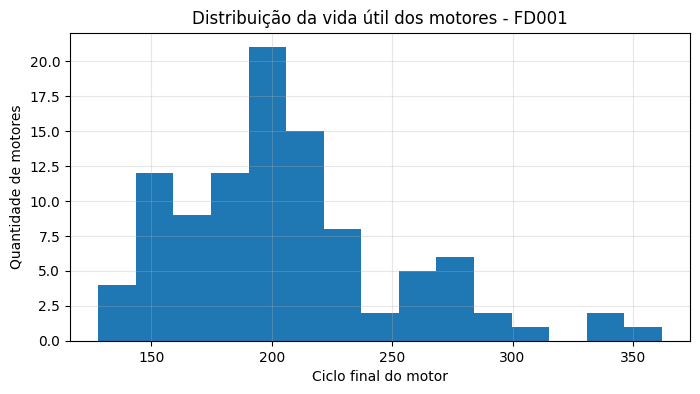

In [44]:
plt.figure(figsize=(8, 4))
plt.hist(life_df["max_cycle"], bins=15)
plt.title("Distribuição da vida útil dos motores - FD001")
plt.xlabel("Ciclo final do motor")
plt.ylabel("Quantidade de motores")
plt.grid(alpha=0.3)
plt.show()


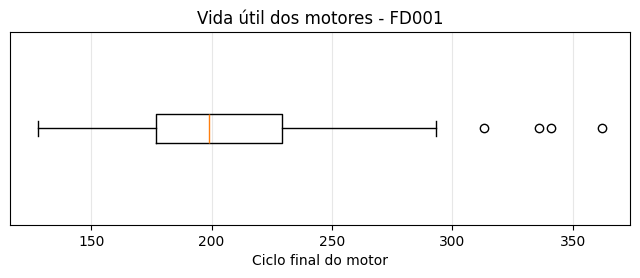

In [45]:
plt.figure(figsize=(8, 2.5))
plt.boxplot(life_df["max_cycle"], vert=False)
plt.title("Vida útil dos motores - FD001")
plt.xlabel("Ciclo final do motor")
plt.yticks([])
plt.grid(alpha=0.3)
plt.show()


Ao observar o desempenho dos motores durante os testes, percebe-se que muitos deles param de funcionar entre 170 e 230 ciclos, sendo que boa parte encerra sua operação por volta dos 200 ciclos. Ainda assim, existem motores que apresentam problemas bem antes, alguns falhando já em 128 ciclos, enquanto outros continuam operando além dos 300 ciclos. Isso mostra que a durabilidade varia bastante de unidade para unidade.

O boxplot ajuda a visualizar melhor essa distribuição, mostrando que a maioria dos resultados se concentra perto da mediana, em torno de 199 ciclos. Também aparecem alguns poucos motores que duram bem mais que os outros, sendo considerados fora do padrão, mas ainda assim fazem parte do grupo analisado. Esses casos mais extremos não devem ser ignorados, pois ajudam a entender como cada motor se comporta ao longo do tempo. Por isso, ao tentar prever quanto tempo cada motor ainda vai funcionar, é importante levar em conta não só o tempo, mas também as informações coletadas pelos sensores durante todo o processo.

#### **5.5 Identificação de sensores constantes ou com baixa variabilidade**

Após a análise da distribuição da vida útil, a etapa seguinte consiste em examinar a variabilidade entre os sensores. No contexto de aprendizado de máquina, Zheng e Casari (2018) explicam que as features correspondem a representações numéricas de aspectos dos dados brutos, e que a qualidade dessas representações impacta diretamente o desempenho do pipeline. Portanto, sensores com baixa variabilidade tendem a contribuir minimamente para a diferenciação entre estados de degradação.

A análise a seguir calcula, para cada sensor, a média, o desvio padrão, o valor mínimo, o valor máximo, o intervalo e o coeficiente de variação. O coeficiente de variação é definido por:

$$
CV = \frac{s}{|\bar{x}|}
$$

em que $CV$ é o coeficiente de variação, $s$ é o desvio padrão e $|\bar{x}|$ é o valor absoluto da média. Essa medida ajuda a comparar a variabilidade relativa entre variáveis que podem estar em escalas diferentes.


O critério $$\sigma_j < 10^{-6}$$ foi empregado para identificar variáveis com variabilidade praticamente nula. O desvio padrão quantifica o afastamento dos valores de uma variável em relação à média; valores próximos de zero indicam que a coluna apresenta variação mínima ao longo das observações. O limiar $10^{-6}$, definido como 0.000001, estabelece uma tolerância numérica reduzida, evitando a necessidade de comparação exata com zero. Essa abordagem é relevante, pois pequenas diferenças podem ocorrer em dados numéricos devido a arredondamentos ou limitações de precisão computacional. Assim, sensores com desvio padrão inferior a esse limiar são considerados constantes ou quase constantes, uma vez que sua variação é irrelevante para fins de modelagem.

In [46]:
sensor_variability_df = train_df[sensor_cols].agg(["mean", "std", "min", "max"]).T

sensor_variability_df["range"] = sensor_variability_df["max"] - sensor_variability_df["min"]
sensor_variability_df["cv"] = sensor_variability_df["std"] / sensor_variability_df["mean"].abs()

sensor_variability_df = sensor_variability_df.sort_values("std")




In [47]:
sensor_variability_df

,mean,std,min,max,range,cv
s1,518.670000,0.000000e+00,518.6700,518.6700,0.0000,0.000000e+00
s10,1.300000,0.000000e+00,1.3000,1.3000,0.0000,0.000000e+00
s19,100.000000,0.000000e+00,100.0000,100.0000,0.0000,0.000000e+00
s18,2388.000000,0.000000e+00,2388.0000,2388.0000,0.0000,0.000000e+00
s16,0.030000,3.469531e-18,0.0300,0.0300,0.0000,1.156510e-16
s5,14.620000,5.329200e-15,14.6200,14.6200,0.0000,3.645143e-16
s6,21.609803,1.388985e-03,21.6000,21.6100,0.0100,6.427569e-05
s15,8.442146,3.750504e-02,8.3249,8.5848,0.2599,4.442595e-03
s8,2388.096652,7.098548e-02,2387.9000,2388.5600,0.6600,2.972471e-05
s13,2388.096152,7.191892e-02,2387.8800,2388.5600,0.6800,3.011559e-05


In [48]:
low_variability_sensors = sensor_variability_df.query("std < 1e-6").index.tolist()

In [49]:
low_variability_sensors

['s1', 's10', 's19', 's18', 's16', 's5']

In [50]:
sensor_variability_df[["std"]].head(10)


,std
s1,0.000000e+00
s10,0.000000e+00
s19,0.000000e+00
s18,0.000000e+00
s16,3.469531e-18
s5,5.329200e-15
s6,1.388985e-03
s15,3.750504e-02
s8,7.098548e-02
s13,7.191892e-02


Os sensores que demonstram desvio padrão muito baixo ou nulo indicam pouca variação ao longo dos registros. Em problemas de previsão de Remaining Useful Life (RUL), essa característica é relevante, pois variáveis quase constantes geralmente possuem baixa capacidade de discriminar motores em diferentes estágios de degradação. Essas informações serão utilizadas posteriormente na etapa de pré-processamento, na qual será avaliada a remoção de sensores com baixo valor informativo.


#### **5.6 Relação entre sensores e RUL**

A correlação é uma medida utilizada para avaliar o grau de associação linear entre duas variáveis. Downey (2015) apresenta a correlação como um método para caracterizar relações entre variáveis, enquanto Mukhiya e Ahmed (2020) distinguem análises univariadas, bivariadas e multivariadas. Nesta etapa, a análise é classificada como bivariada, pois cada sensor é comparado ao RUL.

O coeficiente de correlação de Pearson entre duas variáveis $x$ e $y$ é definido por:

$$
r_{xy} =
\frac{
\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}
}
$$

em que $r_{xy}$ é o coeficiente de correlação, $x_i$ e $y_i$ são as observações das variáveis $x$ e $y$, $\bar{x}$ e $\bar{y}$ são suas médias, e $n$ é a quantidade de observações.

Valores perto de $1$ indicam uma associação linear positiva, enquanto valores próximos de $-1$ indicam uma associação linear negativa. Valores próximos de $0$ sugerem ausência de uma relação linear forte. Ressalta-se que correlação não implica causalidade.


In [51]:
rul_correlation_df = (
    train_df[feature_cols + ["RUL"]]
    .corr(numeric_only=True)[["RUL"]]
    .drop(index="RUL")
    .rename(columns={"RUL": "correlation_with_RUL"})
    .assign(abs_correlation=lambda df: df["correlation_with_RUL"].abs())
    .sort_values("abs_correlation", ascending=False)
)


In [52]:
rul_correlation_df.head(15)

,correlation_with_RUL,abs_correlation
s11,-0.696228,0.696228
s4,-0.678948,0.678948
s12,0.671983,0.671983
s7,0.657223,0.657223
s15,-0.642667,0.642667
s21,0.635662,0.635662
s20,0.629428,0.629428
s2,-0.606484,0.606484
s17,-0.606154,0.606154
s3,-0.584520,0.584520


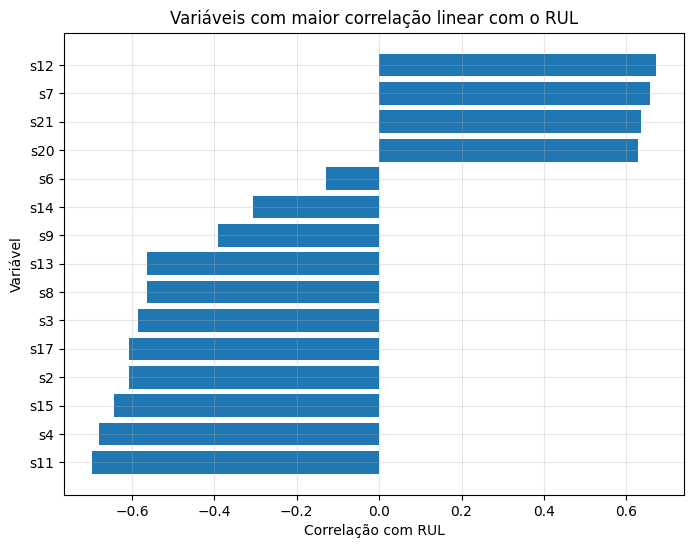

In [53]:
top_corr_df = rul_correlation_df.head(15).sort_values("correlation_with_RUL")

plt.figure(figsize=(8, 6))
plt.barh(top_corr_df.index, top_corr_df["correlation_with_RUL"])
plt.title("Variáveis com maior correlação linear com o RUL")
plt.xlabel("Correlação com RUL")
plt.ylabel("Variável")
plt.grid(alpha=0.3)
plt.show()


O gráfico apresenta as variáveis com maior correlação linear com o RUL. Correlações positivas indicam variáveis que tendem a assumir valores mais altos quando a vida útil restante do motor é maior. Nesse grupo, destacam-se `s12`, `s7`, `s21` e `s20`, o que sugere que valores elevados desses sensores estão associados a motores em estados menos degradados.

Por outro lado, as correlações negativas mostram variáveis que tendem a aumentar à medida que o RUL diminui. Sensores como `s11`, `s4`, `s15`, `s2`, `s17`, `s3`, `s8` e `s13` apresentam esse comportamento, indicando associação com a aproximação da falha. Portanto, uma correlação negativa não implica menor relevância da variável, mas apenas que a relação com o RUL ocorre em sentido oposto.

#### **5.7 Evolução temporal de sensores selecionados**

Como o C-MAPSS é composto por séries temporais, é necessário analisar como determinados sensores variam ao longo dos ciclos. Mukhiya e Ahmed (2020) identificam gráficos de linha como ferramentas apropriadas para visualizar mudanças ao longo do tempo. No contexto deste conjunto de dados, o eixo horizontal representa os ciclos de operação e o eixo vertical corresponde à leitura do sensor.

Essa análise visual é relevante, pois a degradação do motor não ocorre de forma isolada, mas se manifesta como uma sequência de mudanças ao longo dos ciclos.


In [54]:
selected_sensors = ["s2", "s3", "s4", "s7", "s11", "s12", "s15", "s17", "s20", "s21"]
sample_units = [1, 2, 3]


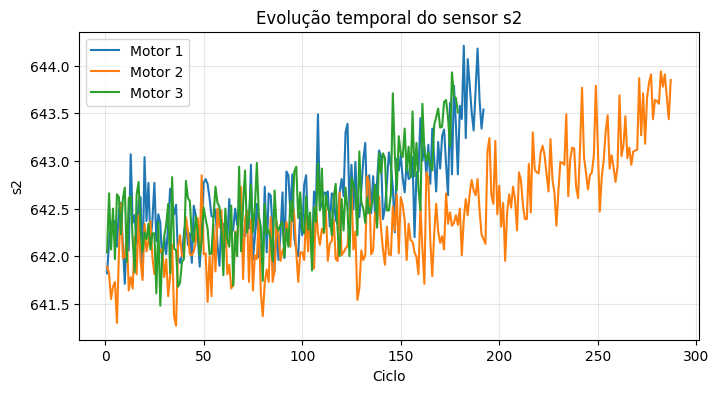

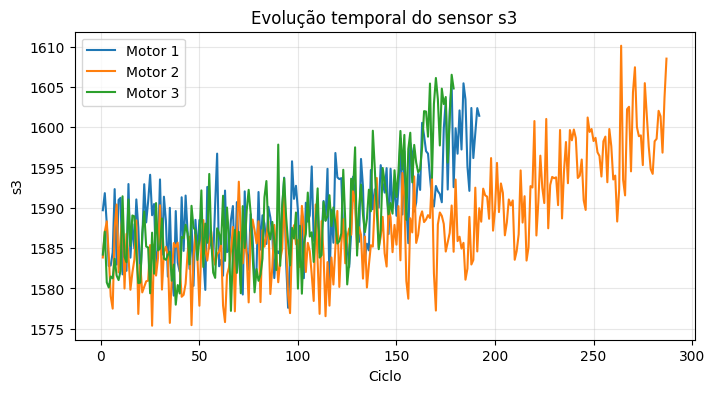

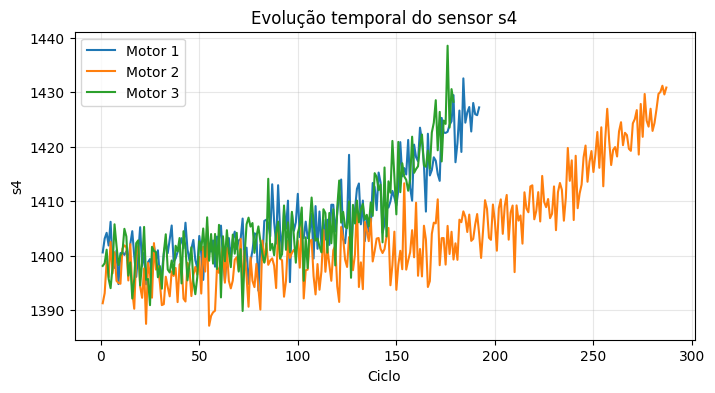

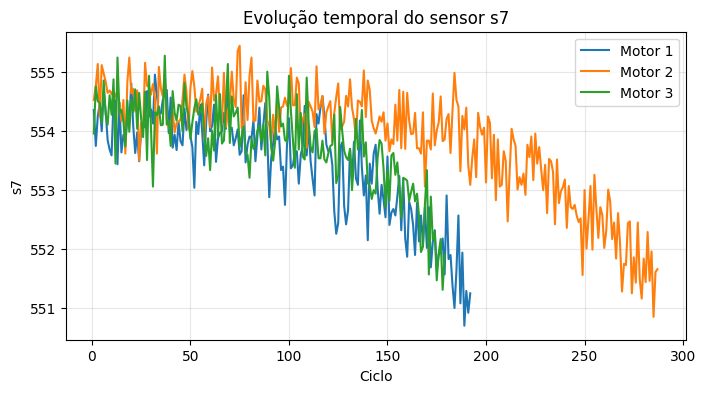

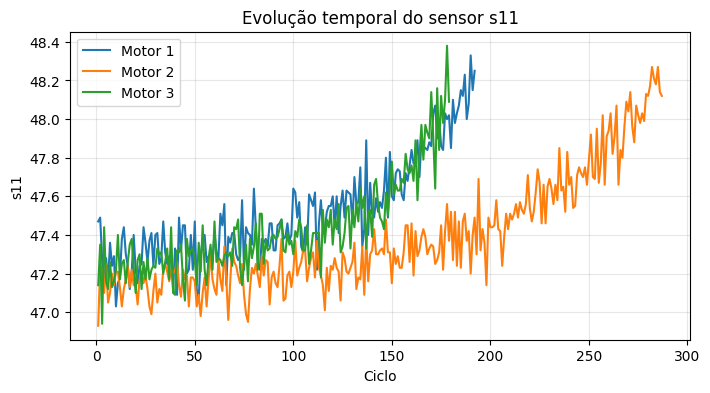

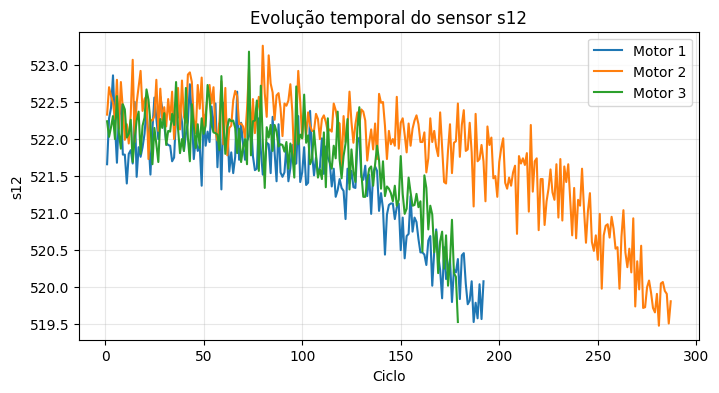

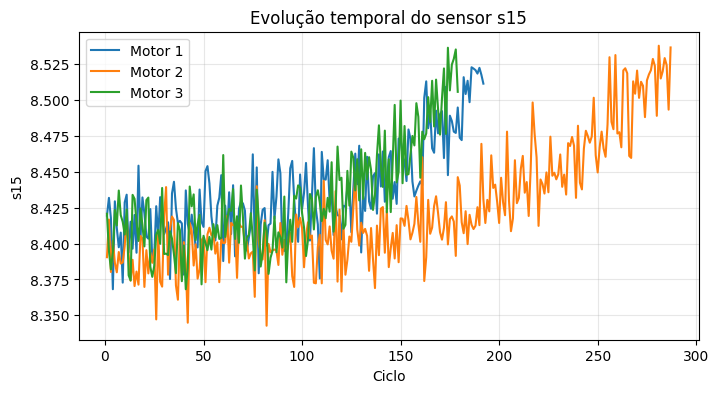

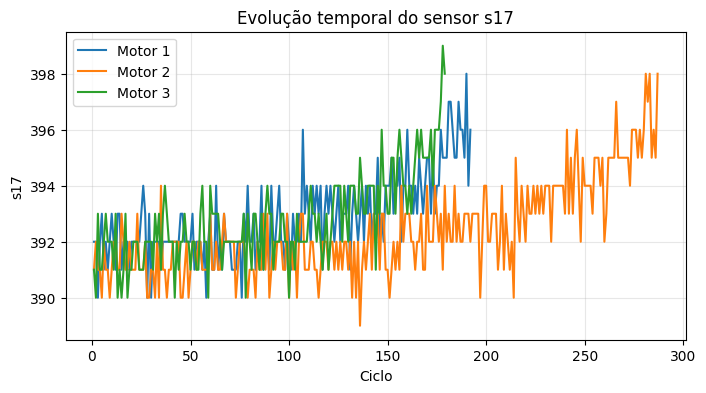

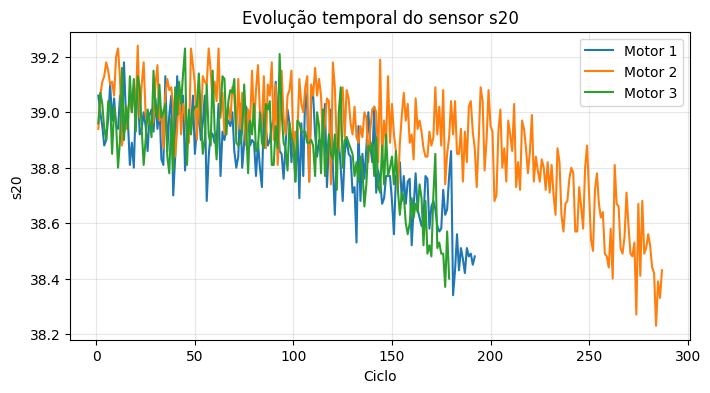

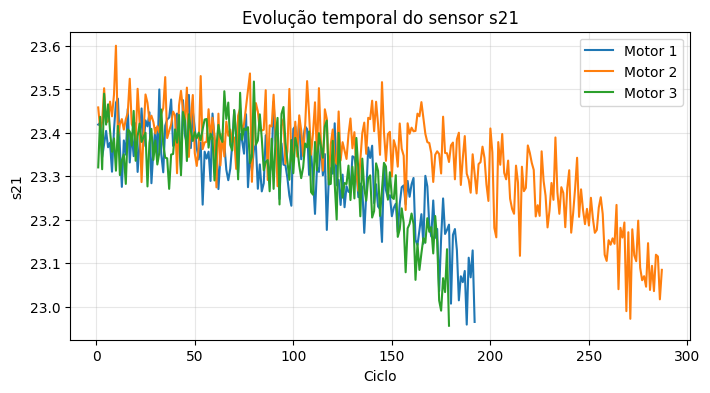

In [55]:
for sensor in selected_sensors:
    plt.figure(figsize=(8, 4))

    for unit in sample_units:
        unit_df = train_df.loc[train_df["unit"] == unit]
        plt.plot(unit_df["cycle"], unit_df[sensor], label=f"Motor {unit}")

    plt.title(f"Evolução temporal do sensor {sensor}")
    plt.xlabel("Ciclo")
    plt.ylabel(sensor)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Ao acompanhar as medições dos sensores ao longo do tempo, é possível perceber como elas mudam conforme os motores vão sendo usados. Nos gráficos, cada motor aparece como uma linha, e o número de ciclos mostra por quanto tempo ele funcionou. Como cada motor dura um tempo diferente, algumas linhas chegam ao fim mais cedo que outras.

De um modo geral, alguns sensores, como `s2`, `s3`, `s4`, `s11`, `s15` e `s17`, costumam mostrar valores mais altos conforme o tempo passa, ou seja, à medida que o motor envelhece. Já outros sensores, como `s7`, `s12`, `s20` e `s21`, normalmente apresentam queda nos valores ao longo dos ciclos, indicando que eles diminuem enquanto o motor se desgasta.

Mesmo com algumas variações de um ciclo para outro, ainda é possível ver essas tendências de subida ou descida. Isso se mostra relevante quando é preciso prever quanto tempo o motor ainda vai funcionar, porque mostra que certos sensores acompanham o desgaste do equipamento. Sensores que mudam de forma constante acabam trazendo informações importantes para criar modelos que tentam prever o tempo restante de vida útil.

Esses resultados também vão de encontro com a análise de correlação feita anteriormente. Sensores que caem ao longo dos ciclos, como `s7`, `s12`, `s20` e `s21`, costumam estar mais altos quando o motor ainda tem bastante tempo de vida, mostrando uma relação positiva com o tempo restante. Já sensores que sobem com o tempo, como `s2`, `s3`, `s4`, `s11`, `s15` e `s17`, tendem a ficar mais altos quando o motor já está perto de parar de funcionar, indicando uma relação negativa com o tempo restante.

Com isso, a **análise temporal dos sensores** tem como objetivo verificar se as medições variam ao longo da vida útil operacional dos motores. Como o conjunto de treinamento acompanha cada motor até a falha, o avanço dos ciclos pode ser interpretado como a progressão do processo de degradação. Dessa forma, ao plotar um sensor em função do ciclo, é possível observerificarar se existe tendência de aumento, redução ou estabilidade à medida que o motor se aproxima do fim da vida útil.

Nos gráficos analisados, cada linha representa um motor distinto e cada gráfico busca representar a evolução do mesmo sensor nesses motores. De forma geral, sensores como `s2`, `s3`, `s4`, `s11`, `s15` e `s17` apresentam tendência de aumento ao longo dos ciclos, enquanto sensores como `s7`, `s12`, `s20` e `s21` apresentam tendência de queda. Esse comportamento sugere que esses sensores captam sinais associados ao avanço da degradação.

As curvas apresentam oscilações locais, o que é comum em dados de sensores. Por essa razão, a interpretação precisa levar em conta a tendência geral no decorrer do tempo, ao invés de variações em ciclos isolados. 

Essa análise é importante para o problema de previsão de *Remaining Useful Life (RUL)*, pois mostra que os sensores não permanecem totalmente estáveis ao longo da vida útil dos motores. É o contrário, parte deles demonstra mudanças à medida que a falha se aproxima. Esses resultados mostram que modelos de aprendizado de máquina podem utilizar essas variáveis para estimar a vida útil remanescente.

#### **5.8 Comportamento médio dos sensores por faixa de RUL**

Além de observar sensores em função do ciclo, também é útil comparar seus valores médios em diferentes faixas de RUL. Essa análise aproxima os sensores do objetivo do problema: estimar a vida útil remanescente. Para isso, o RUL será dividido em grupos, e a média dos sensores será calculada em cada faixa.

Essa etapa é uma forma simples de verificar se o valor médio dos sensores muda conforme o motor se aproxima da falha.


In [56]:
bins = [-1, 25, 50, 75, 100, 125, 150, train_df["RUL"].max()]
labels = ["0-25", "26-50", "51-75", "76-100", "101-125", "126-150", ">150"]

In [57]:
train_df["RUL_group"] = pd.cut(train_df["RUL"], bins, labels=labels)

In [58]:
medias_rul = train_df.groupby("RUL_group")[selected_sensors].mean()

In [59]:
medias_rul

,s2,s3,s4,s7,s11,s12,s15,s17,s20,s21
RUL_group,,,,,,,,,,
0-25,643.422104,1599.319550,1423.705396,551.961431,47.991331,520.215046,8.501171,395.506154,38.541377,23.122436
26-50,642.995460,1594.264624,1415.411096,552.755204,47.733500,520.886728,8.467139,394.197200,38.696092,23.218589
51-75,642.761620,1591.452760,1410.363888,553.219916,47.589268,521.290416,8.448443,393.450400,38.787400,23.273111
76-100,642.604216,1589.475852,1407.504752,553.505220,47.496792,521.542120,8.435967,392.977200,38.841112,23.306177
101-125,642.500048,1588.501872,1405.697112,553.681984,47.441444,521.680104,8.428164,392.676000,38.879988,23.326492
126-150,642.455004,1587.779818,1404.213870,553.817525,47.401481,521.794084,8.423424,392.484323,38.903861,23.342245
>150,642.373565,1586.915566,1402.679201,553.962911,47.349863,521.918120,8.417906,392.255930,38.932845,23.359917


A tabela apresenta as médias dos sensores em diferentes faixas de RUL. Essa análise possibilita a observação do comportamento dos sensores em estágios distintos da vida útil dos motores. Faixas com RUL mais elevado, como `>150`, correspondem a motores ainda distantes da falha, enquanto faixas com RUL mais baixo, como `0-25`, indicam motores próximos ao fim da vida útil.

A comparação das médias entre as faixas revela que sensores como `s2`, `s3`, `s4`, `s11`, `s15` e `s17` apresentam valores médios mais elevados nas faixas de RUL mais baixas, indicando tendência de aumento à medida que o motor se aproxima da falha. Em contraste, sensores como `s7`, `s12`, `s20` e `s21` apresentam valores médios menores nessas faixas, sugerindo redução progressiva ao longo do processo de degradação.

Esse resultado vai de encontro com as análises anteriores de correlação e evolução temporal dos sensores. A organização dos dados em grupos de RUL facilita a interpretação ao permitir a comparação direta do comportamento médio dos sensores em distintos estágios de degradação. Dessa forma, a tabela demonstra que os sensores selecionados exibem padrões consistentes com a evolução da vida útil remanescente, o que pode fornecer informações relevantes para os modelos de previsão de RUL.

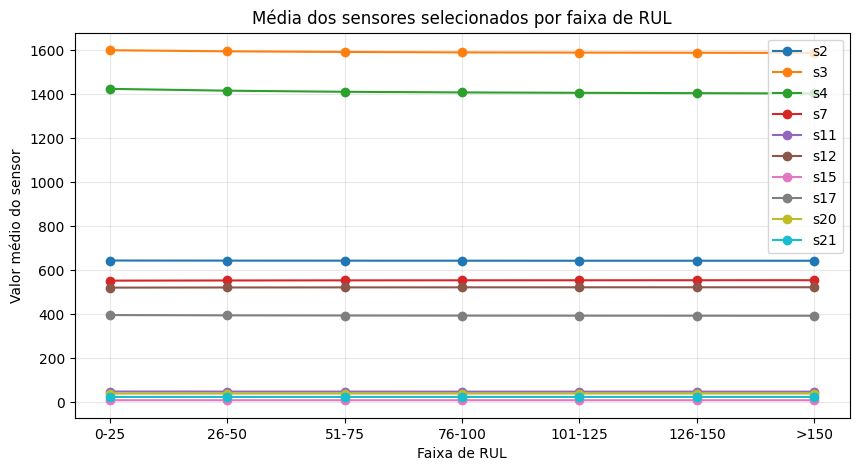

In [60]:
medias_rul.plot(figsize=(10, 5), marker="o")

plt.title("Média dos sensores selecionados por faixa de RUL")
plt.xlabel("Faixa de RUL")
plt.ylabel("Valor médio do sensor")
plt.grid(alpha=0.3)
plt.show()


No gráfico acima, o eixo X representa as faixas de *Remaining Useful Life (RUL)*, que agrupam diferentes intervalos de vida útil remanescente do motor em cada ciclo. As faixas localizadas à esquerda, como `0-25`, indicam situações em que o motor está próximo da falha. Em contraste, as faixas à direita, como `>150`, refletem cenários em que o motor ainda possui uma vida útil remanescente significativamente maior.

O eixo Y indica o valor médio de cada sensor em cada faixa de RUL. Por exemplo, um ponto referente ao sensor `s3` na faixa `0-25` corresponde à média das leituras de `s3` obtidas em todas as observações em que o RUL variou entre 0 e 25 ciclos. Assim, os valores do eixo Y não representam a quantidade de motores ou de ciclos, mas sim a média das medições dos sensores.

Cada sensor opera em uma escala própria, o que faz com que alguns apresentem valores significativamente superiores aos de outros. Sensores como `s3` e `s4` exibem valores absolutos elevados, enquanto sensores como `s15`, `s20` e `s21` apresentam valores absolutos mais baixos. 

De modo geral, o gráfico confirma o comportamento observado na tabela anterior: determinados sensores apresentam valores médios mais elevados quando o RUL é menor, enquanto outros exibem valores médios reduzidos nessas mesmas condições. Esse padrão indica que os sensores selecionados variam conforme o estágio de degradação do motor, aspecto relevante para a previsão da vida útil remanescente.

#### **5.9 Assimetria e curtose dos sensores selecionados**

Além das medidas de posição e dispersão, o formato da distribuição de cada sensor também pode ser analisado. Mukhiya e Ahmed (2020) apresentam a assimetria (*skewness*) e a curtose (*kurtosis*) como medidas descritivas relacionadas à variabilidade e à forma dos dados. De maneira análoga, Bruce e Bruce (2017) associam essas medidas aos momentos estatísticos: enquanto os momentos de ordem inferior descrevem localização e dispersão, os momentos de ordem superior caracterizam a forma da distribuição.

Nesta análise, a assimetria será utilizada para identificar se os valores de um sensor se concentram em determinada região e apresentam cauda mais longa para valores elevados ou reduzidos. A curtose, por sua vez, será empregada para avaliar a tendência da distribuição a apresentar valores extremos. Essa análise é relevante no contexto do C-MAPSS, pois sensores com alta assimetria ou curtose podem indicar distribuições com caudas acentuadas, picos ou valores atípicos, o que pode impactar etapas subsequentes de normalização, seleção de variáveis e modelagem.

Para um sensor $s_j$, o momento central de ordem $k$ pode ser representado por:

$$
\mu_{k,j} = \frac{1}{n}\sum_{i=1}^{n}(x_{ij} - \bar{x}_j)^k
$$

em que $x_{ij}$ representa o valor do sensor $j$ na observação $i$, $\bar{x}_j$ é a média do sensor $j$, $n$ é o número total de observações e $k$ indica a ordem do momento.

A assimetria pode ser representada por:

$$
g_{1,j} = \frac{\mu_{3,j}}{\sigma_j^3}
$$

em que $\mu_{3,j}$ é o terceiro momento central do sensor $j$ e $\sigma_j$ é o seu desvio padrão. Valores próximos de zero indicam uma distribuição mais simétrica. Valores positivos indicam cauda mais longa à direita, enquanto valores negativos indicam cauda mais longa à esquerda.

A curtose em excesso pode ser representada por:

$$
g_{2,j} = \frac{\mu_{4,j}}{\sigma_j^4} - 3
$$

em que $\mu_{4,j}$ é o quarto momento central do sensor $j$. A subtração de 3 ajusta a medida em relação à distribuição normal, que passa a ter curtose em excesso igual a zero. Valores mais altos indicam maior peso nas caudas, sugerindo maior presença de valores extremos ou picos na distribuição.


In [61]:
shape_stats_df = train_df[selected_sensors].agg(["skew", "kurt"]).T
shape_stats_df.columns = ["skewness", "kurtosis_excess"]

shape_stats_df["abs_skewness"] = shape_stats_df["skewness"].abs()
shape_stats_df["abs_kurtosis_excess"] = shape_stats_df["kurtosis_excess"].abs()


In [62]:
shape_stats_df.sort_values("abs_skewness", ascending=False)

,skewness,kurtosis_excess,abs_skewness,abs_kurtosis_excess
s11,0.469329,-0.172192,0.469329,0.172192
s4,0.443194,-0.163681,0.443194,0.163681
s12,-0.442407,-0.144917,0.442407,0.144917
s7,-0.394329,-0.157949,0.394329,0.157949
s15,0.388259,-0.121430,0.388259,0.121430
s20,-0.358445,-0.112829,0.358445,0.112829
s17,0.353126,-0.039174,0.353126,0.039174
s21,-0.350375,-0.117039,0.350375,0.117039
s2,0.316526,-0.112043,0.316526,0.112043
s3,0.308946,0.007762,0.308946,0.007762


A tabela apresenta os valores de assimetria e de curtose em excesso dos sensores selecionados. A coluna `skewness` informa a direção da assimetria da distribuição: valores positivos indicam cauda à direita, enquanto valores negativos indicam cauda à esquerda. A coluna `kurtosis_excess` representa o peso das caudas em relação à distribuição normal. Valores positivos elevados sugerem maior ocorrência de valores extremos ou concentração em torno de determinados pontos, ao passo que valores negativos indicam distribuições mais achatadas.

A análise de assimetria e curtose dos sensores selecionados indica ausência de distorções extremas nas distribuições. Os maiores valores absolutos de assimetria foram observados nos sensores `s11`, `s4` e `s12`, mas todos permanecem abaixo de aproximadamente `0.5`, o que sugere assimetria leve a moderada. Portanto, as distribuições desses sensores apresentam inclinação discreta, sem desequilíbrio acentuado.

Em relação à curtose excessiva, a maioria dos sensores apresentou valores próximos de zero ou ligeiramente negativos. Isso mostra que as distribuições são um pouco mais achatadas do que a normal, sem sinais de caudas pesadas ou de muitos valores fora do esperado. Portanto, para os sensores analisados, não foram encontrados sinais relevantes de distorções ou de extremos.

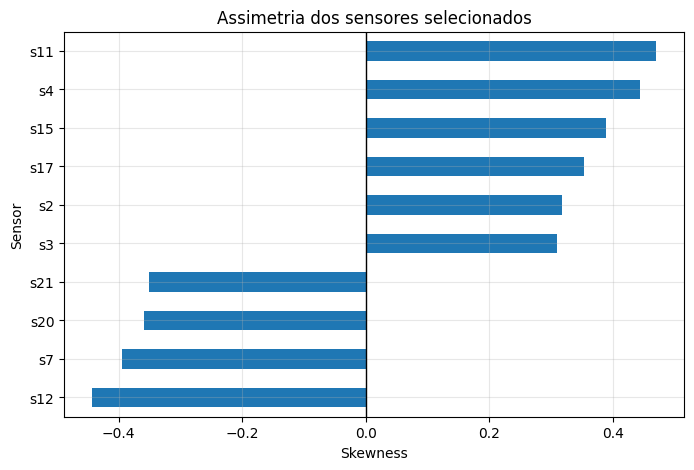

In [63]:
shape_stats_df["skewness"].sort_values().plot(kind="barh", figsize=(8, 5))

plt.title("Assimetria dos sensores selecionados")
plt.xlabel("Skewness")
plt.ylabel("Sensor")
plt.axvline(0, color="black", linewidth=1)
plt.grid(alpha=0.3)
plt.show()


O gráfico apresenta a assimetria dos sensores selecionados. Valores positivos correspondem a distribuições com cauda mais alongada à direita, enquanto valores negativos indicam cauda mais alongada à esquerda. Distribuições com valores próximos de zero tendem a ser mais simétricas. Os sensores `s11`, `s4`, `s15`, `s17`, `s2` e `s3` apresentam assimetria positiva, indicando que a maioria dos dados está concentrada em valores menores, com poucos registros mais altos estendendo a cauda para a direita. Enquanto os sensores `s12`, `s7`, `s20` e `s21` demonstram assimetria negativa, caracterizada por maior concentração de dados em valores elevados e uma cauda direcionada para valores menores.

Apesar dessas diferenças, os valores de assimetria variam entre `-0.45` e `0.47`, sendo considerados moderados. Portanto, os sensores não apresentam distribuições fortemente assimétricas. Em suma, não foram identificadas distorções tão extremas.


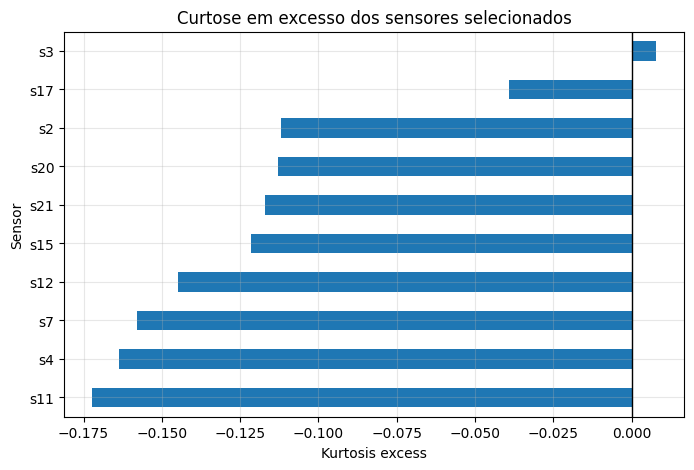

In [64]:
shape_stats_df["kurtosis_excess"].sort_values().plot(kind="barh", figsize=(8, 5))

plt.title("Curtose em excesso dos sensores selecionados")
plt.xlabel("Kurtosis excess")
plt.ylabel("Sensor")
plt.axvline(0, color="black", linewidth=1)
plt.grid(alpha=0.3)
plt.show()


O gráfico apresenta a curtose excessiva dos sensores selecionados. A curtose excessiva compara o formato da distribuição de cada sensor à distribuição normal, utilizando esta última como referência em torno de zero. Valores positivos indicam maior peso nas caudas ou maior concentração de valores extremos, enquanto valores negativos indicam distribuições mais achatadas, com caudas menos pronunciadas.

Os resultados indicam que quase todos os sensores apresentam curtose excessiva negativa, próxima de zero. Esse resultado sugere que as distribuições dos sensores selecionados são levemente mais achatadas do que a distribuição normal, sem evidências significativas de caudas pesadas ou presença acentuada de valores extremos. O sensor `s3` apresenta valor muito próximo de zero e levemente positivo, indicando comportamento semelhante ao da distribuição normal nesse aspecto.

De modo geral, a análise da curtose indica ausência de indícios relevantes de valores extremos entre os sensores analisados. Esses resultados corroboram as conclusões obtidas na análise de assimetria, indicando que, apesar de pequenas variações nas distribuições, não foram identificadas distorções significativas que exijam intervenções nesta etapa.


### **6. Seleção Inicial de Variáveis e Pré-processamento**

Após a análise exploratória, a próxima etapa consiste em organizar o conjunto de dados para a modelagem. Essa parte prepara a matriz de entrada, define a variável-alvo e remove as informações que não serão utilizadas como atributos preditivos. Zheng e Casari (2018) definem a engenharia de atributos como o processo de extrair e transformar dados brutos em representações adequadas para modelos de aprendizado de máquina. James et al. (2013) apresentam o aprendizado supervisionado como um problema no qual um conjunto de variáveis de entrada é utilizado para estimar uma variável de saída. As variáveis de entrada serão os sensores selecionados a partir da EDA, enquanto a variável de saída será o `RUL`. 

#### **6.1 Organização dos grupos de variáveis**

Inicialmente, as colunas são organizadas conforme o papel que desempenham no conjunto de dados. Essa diferenciação possibilita definir quais dados serão utilizados no processo de modelagem e quais permanecerão apenas como informações complementares. Como exemplo, as colunas `unit` e `cycle` servem para identificar o motor e o ciclo operacional, mas não correspondem a sensores. A coluna `RUL` representa a variável-alvo, enquanto `max_cycle` é uma variável auxiliar criada para auxiliar no cálculo dessa meta.

In [65]:
metadata_cols = ["unit", "cycle"]
operational_cols = ["op1", "op2", "op3"]
sensor_cols = [f"s{i}" for i in range(1, 22)]
target_col = "RUL"
target_derived_cols = ["max_cycle", "RUL_group"]

# Um humano faria assim: direto, sem checagens defensivas desnecessárias
resumo_grupos = [
    {"grupo": "Identificação e tempo", "colunas": ", ".join(metadata_cols)},
    {"grupo": "Condições operacionais", "colunas": ", ".join(operational_cols)},
    {"grupo": "Sensores", "colunas": ", ".join(sensor_cols)},
    {"grupo": "Variável-alvo", "colunas": target_col},
    {"grupo": "Variáveis derivadas", "colunas": ", ".join(target_derived_cols)}
]

column_groups_df = pd.DataFrame(resumo_grupos)


In [66]:
column_groups_df

,grupo,colunas
0,Identificação e tempo,"unit, cycle"
1,Condições operacionais,"op1, op2, op3"
2,Sensores,"s1, s2, s3, s4, s5, s6, s7, s8, s9, s10, s11, ..."
3,Variável-alvo,RUL
4,Variáveis derivadas,"max_cycle, RUL_group"


#### **6.2 Definição das variáveis de entrada**

A EDA mostrou que alguns sensores apresentam baixa ou nenhuma variabilidade no FD001, enquanto outros apresentam relação visual e estatística mais evidente com a degradação. Por isso, a primeira versão da modelagem será construída com os sensores previamente selecionados na análise exploratória.

As colunas `unit`, `max_cycle`, `RUL` e `RUL_group` não serão usadas como atributos de entrada. A coluna `unit` serve apenas como identificador do motor. A coluna `max_cycle` foi usada para calcular o RUL durante o treinamento e, portanto, contém informações diretas sobre o momento de falha. A coluna `RUL_group` também foi criada a partir do próprio RUL para fins de análise exploratória.

In [67]:
removed_feature_cols = ["unit", "max_cycle", "RUL", "RUL_group", "op1", "op2", "op3"]

model_feature_cols = [sensor for sensor in selected_sensors if sensor not in low_variability_sensors]

print(f"Features para o modelo ({len(model_feature_cols)}): {model_feature_cols}")
print(f"Colunas descartadas: {len(removed_feature_cols) + len(low_variability_sensors)}")

Features para o modelo (10): ['s2', 's3', 's4', 's7', 's11', 's12', 's15', 's17', 's20', 's21']
Colunas descartadas: 13


O resultado acima mostra a seleção de variáveis. Os sensores selecionados serão utilizados como atributos do modelo, enquanto os sensores constantes ou quase constantes serão removidos por não apresentarem variação informativa no FD001. As colunas derivadas do alvo e os identificadores são mantidos no conjunto de dados apenas para controle, análise e validação, mas não são incluídos como variáveis preditoras.

#### **6.3 Construção de $X$ e $y$**

No contexto do aprendizado supervisionado, os dados geralmente são representados por uma matriz de atributos $X$ e por um vetor de resposta $y$. Neste projeto, cada linha de $X$ representa uma observação de um motor em um ciclo específico, caracterizada pelas leituras dos sensores selecionados. O vetor $y$ armazena o RUL correspondente a cada uma dessas observações.

Essa estrutura pode ser representada da seguinte forma:

$$
X = \begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1p} \\
x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
$$

$$
y = \begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

em que $n$ representa o número de observações, $p$ representa o número de sensores selecionados, $x_{ij}$ é o valor da variável $j$ na observação $i$ e $y_i$ é o RUL associado à observação $i$.

In [68]:
X_train_raw = train_df[model_feature_cols]
y_train = train_df[target_col]
train_groups = train_df["unit"]

In [69]:
X_test_last_raw = test_last_cycle_df[model_feature_cols]
y_test = test_last_cycle_df[target_col]

In [70]:
print(f"Treino -> X: {X_train_raw.shape}, y: {y_train.shape}")
print(f"Teste  -> X: {X_test_last_raw.shape}, y: {y_test.shape}")

Treino -> X: (20631, 10), y: (20631,)
Teste  -> X: (100, 10), y: (100,)


A matriz `X_train_raw` armazena os atributos de entrada do conjunto de treinamento, enquanto `y_train` contém os valores correspondentes de RUL. A variável `train_groups` registra o identificador do motor de cada observação, sendo relevante para a etapa subsequente, na qual a divisão entre treino e validação deve respeitar as unidades da frota. Para o conjunto de teste, considera-se apenas o último ciclo disponível de cada motor, pois é nesse ponto que o RUL verdadeiro, fornecido no arquivo `RUL_FD001.txt`, é comparado à previsão do modelo.

#### **6.4 Análise de consistência**

Antes da divisão entre treino e validação e do início da modelagem, é fundamental verificar se a matriz de atributos está livre de valores ausentes e se nenhuma coluna proibida foi incluída inadvertidamente como variável de entrada. Essa verificação minimiza o risco de erros subsequentes e contribui para a reprodutibilidade do pipeline experimental.

In [71]:
forbidden_cols = {"unit", "max_cycle", "RUL", "RUL_group"}
leaked_cols = [col for col in model_feature_cols if col in forbidden_cols]

In [72]:
print(f"Valores nulos no treino: {X_train_raw.isna().sum().sum()}")
print(f"Valores nulos no teste: {X_test_last_raw.isna().sum().sum()}")
print(f"Vazamento de dados (Leakage): {leaked_cols if leaked_cols else 'Nenhum'}")

Valores nulos no treino: 0
Valores nulos no teste: 0
Vazamento de dados (Leakage): Nenhum


A análise mostra que os dados estão corretos para a próxima etapa. Não foram identificados valores ausentes nas matrizes de entrada, dispensando o uso da técnica de imputação.

#### **6.5 Observação sobre normalização**

Os sensores do C-MAPSS apresentam diferentes escalas de medição. Alguns sensores registram valores na ordem de dezenas, enquanto outros operam em centenas ou milhares. Essa variação de escala pode impactar algoritmos sensíveis à magnitude das variáveis, especialmente aqueles baseados em distância, regularização ou otimização numérica. Zheng e Casari (2018) destacam a normalização e a padronização como técnicas essenciais de engenharia de atributos para dados numéricos. Além disso, os slides da disciplina ressaltam que variáveis com magnitudes desproporcionais podem comprometer o cálculo de distâncias e a convergência de algoritmos.



A padronização pelo score-$z$ converte cada valor $x_{ij}$ de uma variável $j$ em:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

em que $z_{ij}$ é o valor padronizado, $x_{ij}$ é o valor original da variável $j$ na observação $i$, $\mu_j$ é a média da variável $j$ e $\sigma_j$ é o desvio padrão da variável $j$.

In [73]:
scaling_cols = model_feature_cols.copy()

In [74]:
print(f"Total de colunas para normalizar: {len(scaling_cols)}")

Total de colunas para normalizar: 10


#### **6.6 Salvamento dos dados processados**

Por fim, uma versão processada dos dados é criada, contendo apenas identificadores, sensores selecionados e a variável-alvo. Essa versão facilita a reprodutibilidade das etapas subsequentes, ao separar o conjunto já organizado para modelagem do conjunto bruto original.

In [75]:
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [76]:
cols_to_save = metadata_cols + model_feature_cols + [target_col]

train_path = PROCESSED_DIR / "FD001_train_processed.csv"
test_path = PROCESSED_DIR / "FD001_test_last_cycle_processed.csv"

train_df[cols_to_save].to_csv(train_path, index=False)
test_last_cycle_df[cols_to_save].to_csv(test_path, index=False)

In [77]:
print(f"Treino salvo: {train_path}")
print(f"Teste salvo: {test_path}")

Treino salvo: data\processed\FD001_train_processed.csv
Teste salvo: data\processed\FD001_test_last_cycle_processed.csv


In [78]:
train_df[cols_to_save].head()

,unit,cycle,s2,s3,s4,s7,s11,s12,s15,s17,s20,s21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,47.47,521.66,8.4195,392,39.06,23.4190,191
1,1,2,642.15,1591.82,1403.14,553.75,47.49,522.28,8.4318,392,39.00,23.4236,190
2,1,3,642.35,1587.99,1404.20,554.26,47.27,522.42,8.4178,390,38.95,23.3442,189
3,1,4,642.35,1582.79,1401.87,554.45,47.13,522.86,8.3682,392,38.88,23.3739,188
4,1,5,642.37,1582.85,1406.22,554.00,47.28,522.19,8.4294,393,38.90,23.4044,187


Neste contexto, o vazamento de dados acontece quando uma variável fornece ao modelo informações que não estariam disponíveis no momento da previsão. Esse fenômeno pode levar o algoritmo a apresentar bons resultados durante o treinamento ou validação por motivos artificiais, pois passa a utilizar informações derivadas do próprio alvo ou de eventos futuros do motor. Dessa forma, a coluna `RUL` não deve ser incluída entre as variáveis de entrada, pois representa exatamente o valor a ser previsto. De modo semelhante, a coluna `max_cycle` também não deve ser utilizada como entrada, pois é calculada a partir do último ciclo observado de cada motor no conjunto de treinamento. Como o RUL é obtido pela diferença entre `max_cycle` e `cycle`, a inclusão de `max_cycle` permitiria ao modelo acessar indiretamente a informação sobre o momento da falha do motor, o que não estaria disponível em uma situação real de predição. Portanto, essas colunas são mantidas apenas para controle e para a construção do alvo, sendo excluídas da matriz de entrada dos modelos.

Até aqui, o conjunto de treinamento encontra-se estruturado de forma adequada para a modelagem supervisionada. Os sensores que compõem a matriz de entrada foram definidos; o RUL foi mantido como variável-alvo; colunas auxiliares foram preservadas exclusivamente para controle; e variáveis com potencial de vazamento foram excluídas da entrada dos modelos. A etapa subsequente consiste na divisão treino-validação por unidade, assegurando que ciclos do mesmo motor não estejam presentes simultaneamente nos conjuntos de treino e de validação.

Além do vazamento por variáveis, é importante evitar vazamento na divisão dos dados. Como cada motor possui várias linhas correspondentes aos seus ciclos de operação, uma divisão aleatória por linhas pode resultar na presença de ciclos do mesmo motor tanto no conjunto de treinamento quanto no de validação. Nessa situação, o modelo avaliaria motores parcialmente conhecidos, o que resultaria em uma estimativa de desempenho excessivamente otimista. Portanto, a próxima etapa consiste em realizar a divisão por unidade, assegurando que os motores utilizados na validação não estejam presentes no treinamento.



### **7. Divisão Treino-Validação por Unidade**

Após a definição da matriz de atributos e da variável-alvo, a etapa subsequente consiste em separar uma parte do conjunto de treinamento para validação. Essa separação permite avaliar o desempenho inicial dos modelos em dados não utilizados no ajuste dos parâmetros. James et al. (2013) e Hastie, Tibshirani e Friedman (2009) destacam a importância de avaliar modelos em dados externos ao conjunto de treinamento, pois o objetivo é estimar o desempenho em novas observações, e não apenas ajustar os dados conhecidos. Theodoridis (2026) também enfatiza a validação como etapa fundamental para avaliar a capacidade de generalização dos modelos.

No presente conjunto de dados, a divisão não deve ser realizada aleatoriamente por linhas. Cada motor apresenta múltiplas observações ao longo dos ciclos, e uma divisão aleatória poderia resultar na presença de ciclos do mesmo motor tanto no conjunto de treinamento quanto no de validação. Isso levaria à avaliação do modelo em unidades parcialmente conhecidas, o que pode resultar em uma estimativa otimista de desempenho. Portanto, a divisão será realizada por `unit`, assegurando que todos os ciclos de um mesmo motor permaneçam em apenas um dos conjuntos.

A condição esperada é:

$$
U_{treino} \cap U_{validação} = \varnothing
$$

em que $U_{treino}$ representa o conjunto de motores usados no treinamento e $U_{validação}$ representa o conjunto de motores usados na validação. Assim, nenhum motor da validação aparece no treinamento.

#### **7.1 Separação por grupos**

A divisão por unidade será realizada utilizando o identificador do motor como critério de agrupamento. Assim, a separação guarda a estrutura do conjunto de dados, em que cada unidade corresponde a um motor e todas as suas medições ao longo dos ciclos ficam agrupadas. O conjunto de validação será composto por aproximadamente 20% dos motores presentes no conjunto de treinamento.

In [86]:
from sklearn.model_selection import GroupShuffleSplit

In [87]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(splitter.split(X_train_raw, y_train, groups=train_groups))

In [88]:
X_train_split = X_train_raw.iloc[train_idx].copy()
X_val_split = X_train_raw.iloc[val_idx].copy()

y_train_split = y_train.iloc[train_idx].copy()
y_val_split = y_train.iloc[val_idx].copy()

groups_train_split = train_groups.iloc[train_idx].copy()
groups_val_split = train_groups.iloc[val_idx].copy()

#### **7.2 Verificação da divisão**

Após a separação, é preciso verificar se há sobreposição de motores entre os conjuntos de treino e de validação. Se algum motor estiver presente em ambos os conjuntos, a divisão não será considerada adequada para este problema.

In [90]:
train_units = set(groups_train_split.unique())
val_units = set(groups_val_split.unique())

overlap_units = train_units.intersection(val_units)

In [91]:
print(f"Motores no treino: {len(train_units)}")
print(f"Motores na validação: {len(val_units)}")
print(f"Motores em comum: {len(overlap_units)}")

Motores no treino: 80
Motores na validação: 20
Motores em comum: 0


In [92]:
split_summary_df = pd.DataFrame({
    "set": ["Treino", "Validação"],
    "rows": [len(X_train_split), len(X_val_split)],
    "engines": [len(train_units), len(val_units)],
    "mean_RUL": [y_train_split.mean(), y_val_split.mean()],
    "min_RUL": [y_train_split.min(), y_val_split.min()],
    "max_RUL": [y_train_split.max(), y_val_split.max()]
}).round(2)

split_summary_df.round(2)

,set,rows,engines,mean_RUL,min_RUL,max_RUL
0,Treino,16561,80,108.38,0,361
1,Validação,4070,20,105.49,0,268


A divisão entre os conjuntos de treino e de validação foi feita por unidade, de modo que cada motor completo foi incluído em apenas um dos conjuntos. O conjunto de treinamento incluiu 80 motores e 16.561 observações, enquanto o de validação incluiu 20 motores e 4.070 observações. A diferença na proporção de linhas em relação à divisão 80/20 se deve ao fato de que cada motor apresenta uma vida útil distinta, o que resulta em diferentes quantidades de ciclos registrados.

Os valores médios de RUL permaneceram próximos entre os conjuntos, com média de 108,38 no treinamento e de 105,49 na validação. Esse resultado mostra que a divisão preservou satisfatoriamente a distribuição geral da variável-alvo. Em ambos os conjuntos, o menor valor de RUL é igual a zero, o que evidencia a presença de registros do ciclo final dos motores. O maior valor de RUL foi observado no conjunto de treinamento, em comparação ao de validação, o que indica que motores com maior vida útil foram alocados ao conjunto de treinamento. Ainda assim, a divisão é considerada adequada para a etapa de validação, pois impede que ciclos do mesmo motor estejam presentes simultaneamente em ambos os conjuntos.

#### **7.3 Distribuição do RUL após a divisão**

Além de verificar a separação dos motores, é relevante comparar a distribuição do RUL entre os conjuntos de treino e de validação. Essa análise permite verificar se o conjunto de validação inclui exemplos em diferentes estágios de vida útil, abrangendo motores tanto distantes da falha quanto próximos do fim da vida operacional.

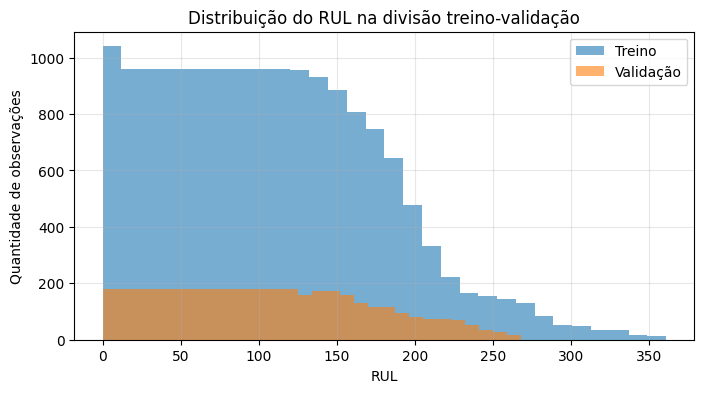

In [84]:
plt.figure(figsize=(8, 4))
plt.hist(y_train_split, bins=30, alpha=0.6, label="Treino")
plt.hist(y_val_split, bins=30, alpha=0.6, label="Validação")

plt.title("Distribuição do RUL na divisão treino-validação")
plt.xlabel("RUL")
plt.ylabel("Quantidade de observações")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

O gráfico apresenta a comparação da distribuição do RUL após a divisão entre os conjuntos de treinamento e de validação. O conjunto de treinamento possui mais observações, pois inclui 80 motores, enquanto o de validação contém apenas 20. Consequentemente, as barras referentes ao treinamento apresentam alturas superiores.

Apesar da diferença no número de observações, o conjunto de validação apresenta valores distribuídos em diversas faixas de RUL, abrangendo tanto regiões próximas à falha quanto regiões com maior vida útil remanescente. Essa característica é importante, pois permite avaliar o modelo em diferentes estágios de degradação, em vez de restringi-lo a uma única condição.

Observa-se também que o conjunto de treinamento mostra valores máximos de RUL superiores aos do conjunto de validação. Esse resultado indica que os motores com maior vida útil foram alocados no treinamento, conforme já mostrado na tabela da divisão. 

#### **7.4 Preparação para a próxima etapa**

Com a divisão treino-validação definida, os dados estão prontos para a etapa de modelagem. A normalização ainda não foi aplicada nesta fase, pois precisa ser ajustada apenas com os dados de treinamento e, depois, aplicada à validação.

In [93]:
print(f"X_train_split: {X_train_split.shape}")
print(f"X_val_split:   {X_val_split.shape}")
print(f"y_train_split: {y_train_split.shape}")
print(f"y_val_split:   {y_val_split.shape}")

X_train_split: (16561, 10)
X_val_split:   (4070, 10)
y_train_split: (16561,)
y_val_split:   (4070,)


### **Referências Bibliográficas**

- LIU, Y.; FREDERICK, D. K.; DECASTRO, J. A.; LITT, J. S.; CHAN, W. W. **User’s Guide for the Commercial Modular Aero-Propulsion System Simulation (C-MAPSS), Version 2**. NASA/TM—2012-217432, 2012.
- SAXENA, A.; GOEBEL, K.; SIMON, D.; EKLUND, N. **Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation**. Proceedings of the 1st International Conference on Prognostics and Health Management, 2008.
- AVSAR, R. **Enhancing prognostic model interpretability for advanced engine failure prediction using prognostic metrics and explainable AI**. *The Aeronautical Journal*, 2026.
- CHOLA, A.; RASTOGI, R.; KAUR, P.; CHAUDHARY, A.; BISWAS, D. **Predictive Analytics Beyond the Hype: A Comprehensive Comparison of LSTM, XGBoost and LightGBM with Emphasis on RMSE and CPU Utilization**. 2024.
- GOYAL, N.; SACHDEVA, R. **Application of Machine Learning in Predictive Maintenance**. 2025.
- HATIPOĞLU, A.; YILMAZ, E. **A Matrix-Statistics-Aware Attention Mechanism for Robust RUL Estimation in Aero-Engines**. *Applied Sciences*, v. 16, n. 169, 2026.
- JIA, Z.; XIAO, Z.; SHI, Y. **Remaining Useful Life Prediction of Equipment Based on XGBoost**. In: *The 5th International Conference on Computer Science and Application Engineering (CSAE 2021)*, 2021. DOI: 10.1145/3487075.3487134.
- KHALIFEH, A.; ALMEQDADI, S. **Machine Learning-Based Remaining Useful Life Predictions and Its Application on Predictive Maintenance**. In: *2024 22nd International Conference on Research and Education in Mechatronics (REM)*, 2024.
- ZHAN, Y.; WANG, Z.; XU, Z. **Remaining Useful Life Prediction Considering Data and Model Uncertainties**. In: *2023 9th International Symposium on System Security, Safety, and Reliability (ISSSR)*, 2023.
- BRUCE, P.; BRUCE, A. **Practical Statistics for Data Scientists: 50 Essential Concepts**. Sebastopol: O'Reilly Media, 2017.
- DOWNEY, A. B. **Think Stats: Exploratory Data Analysis**. 2. ed. Sebastopol: O'Reilly Media, 2015.
- MUKHIYA, S. K.; AHMED, U. **Hands-On Exploratory Data Analysis with Python**. Birmingham: Packt Publishing, 2020.
- ZHENG, A.; CASARI, A. **Feature Engineering for Machine Learning: Principles and Techniques for Data Scientists**. Sebastopol: O'Reilly Media, 2018.
- VITOR, G. B. **PCO213 - Aprendizado de Máquina/Mineração de Dados: Aula 02**. Universidade Federal de Itajubá, 2026.
- JAMES, G.; WITTEN, D.; HASTIE, T.; TIBSHIRANI, R. **An Introduction to Statistical Learning: with Applications in R**. New York: Springer, 2013.
- HASTIE, T.; TIBSHIRANI, R.; FRIEDMAN, J. **The Elements of Statistical Learning: Data Mining, Inference, and Prediction**. 2. ed. New York: Springer, 2009.
- THEODORIDIS, S. **Machine Learning: From the Classics to Deep Networks, Transformers, and Diffusion Models**. 3. ed. London: Academic Press, 2026.
